# OpenCV Smart Axis Detection

Deze notebook probeert slimmer x-assen / category axes te detecteren in chart-afbeeldingen.

Deze versie combineert meerdere signalen:

1. **Bar alignment**  
   Als meerdere bars op dezelfde lijn starten/eindigen, is dat waarschijnlijk een as.

2. **Dark axis line support**  
   Als er op die plek ook een donkere/zwarte dikkere lijn staat, wordt de kandidaat sterker.

3. **Divider filtering**  
   Niet elke lijn is een as. Sommige lijnen zijn dividers, borders of tabelregels. Die krijgen strafpunten.

4. **Orientation aware**
   - Horizontale bars → as staat meestal links.
   - Verticale bars → x-as staat meestal onderaan.
   - Er kunnen meerdere grafieken in één afbeelding zitten.

## Kleuren in output

- Oranje boxen = horizontale bar-kandidaten
- Roze boxen = verticale bar-kandidaten
- Blauw = linker/category-as voor horizontale bar charts
- Groen = onderliggende x-as voor verticale bar charts

De tabel onderaan laat de score en redenen zien.


In [ ]:
# Run once if packages are missing
%pip install opencv-python matplotlib numpy pandas

In [1]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("OpenCV version:", cv2.__version__)

OpenCV version: 4.13.0


## 1. Settings

Pas `IMAGE_PATH` aan naar jouw afbeelding.

Voorbeeld:

```python
IMAGE_PATH = Path("../Dataset/Compliant/chart1.png")
```


In [2]:
IMAGE_PATH = Path("../Dataset/Compliant/7.png")

OUTPUT_DIR = Path("../output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# General mask settings
DARK_THRESHOLD = 215
SATURATION_MAX = 140
BORDER_MARGIN_RATIO = 0.03

# Bar candidate settings
MIN_HBAR_WIDTH = 35
MIN_HBAR_HEIGHT = 6
MAX_HBAR_HEIGHT = 35
MIN_HBAR_ASPECT = 2.2

MIN_VBAR_HEIGHT = 35
MIN_VBAR_WIDTH = 6
MAX_VBAR_WIDTH = 35
MIN_VBAR_ASPECT = 2.2

# Alignment settings
ALIGNMENT_TOLERANCE_X = 8
ALIGNMENT_TOLERANCE_Y = 8
MIN_BARS_ON_AXIS = 2

# Axis line support
AXIS_LINE_SEARCH_RADIUS = 5
MIN_AXIS_LINE_DARK_RATIO = 0.35

# Divider filtering
DIVIDER_LENGTH_RATIO = 0.55
DIVIDER_LOW_BAR_SUPPORT_PENALTY = 180
BORDER_PENALTY = 250

# Orientation decision
DOMINANCE_RATIO = 1.5

# Output
MAX_AXES_TO_DRAW = 15
MIN_SCORE_TO_SHOW = 120

## 2. Helper functions

In [3]:

def show_image(title, image, figsize=(12, 8), cmap=None):
    plt.figure(figsize=figsize)
    if len(image.shape) == 2:
        plt.imshow(image, cmap=cmap or "gray")
    else:
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()


def load_image(path):
    image = cv2.imread(str(path))
    if image is None:
        raise FileNotFoundError(f"Image not found: {path}")
    return image


def create_dark_mask(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    saturation = hsv[:, :, 1]

    dark = gray < DARK_THRESHOLD
    low_sat = saturation < SATURATION_MAX

    mask = np.zeros_like(gray, dtype=np.uint8)
    mask[dark & low_sat] = 255

    # Close small gaps inside bars and hatched bars
    close_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 3))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, close_kernel, iterations=1)

    return mask


def remove_image_border(mask):
    h, w = mask.shape[:2]
    mx = int(w * BORDER_MARGIN_RATIO)
    my = int(h * BORDER_MARGIN_RATIO)

    cleaned = mask.copy()
    cleaned[:my, :] = 0
    cleaned[h-my:, :] = 0
    cleaned[:, :mx] = 0
    cleaned[:, w-mx:] = 0
    return cleaned


def detect_horizontal_bars(mask):
    h, w = mask.shape[:2]

    kernel_w = max(25, int(w * 0.035))
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_w, 3))
    connected = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)

    contours, _ = cv2.findContours(connected, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    bars = []
    for cnt in contours:
        x, y, bw, bh = cv2.boundingRect(cnt)
        aspect = bw / max(bh, 1)

        if bw < MIN_HBAR_WIDTH:
            continue
        if bh < MIN_HBAR_HEIGHT or bh > MAX_HBAR_HEIGHT:
            continue
        if aspect < MIN_HBAR_ASPECT:
            continue
        if bw > w * 0.70:
            continue

        mx = int(w * BORDER_MARGIN_RATIO)
        my = int(h * BORDER_MARGIN_RATIO)
        if x <= mx or y <= my or x + bw >= w - mx or y + bh >= h - my:
            continue

        bars.append({
            "type": "horizontal_bar",
            "x": int(x),
            "y": int(y),
            "w": int(bw),
            "h": int(bh),
            "x_left": int(x),
            "x_right": int(x + bw),
            "y_top": int(y),
            "y_bottom": int(y + bh),
            "y_center": int(y + bh / 2),
            "aspect": float(aspect)
        })

    return bars, connected


def detect_vertical_bars(mask):
    h, w = mask.shape[:2]

    kernel_h = max(25, int(h * 0.035))
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, kernel_h))
    connected = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)

    contours, _ = cv2.findContours(connected, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    bars = []
    for cnt in contours:
        x, y, bw, bh = cv2.boundingRect(cnt)
        aspect = bh / max(bw, 1)

        if bh < MIN_VBAR_HEIGHT:
            continue
        if bw < MIN_VBAR_WIDTH or bw > MAX_VBAR_WIDTH:
            continue
        if aspect < MIN_VBAR_ASPECT:
            continue
        if bh > h * 0.70:
            continue

        mx = int(w * BORDER_MARGIN_RATIO)
        my = int(h * BORDER_MARGIN_RATIO)
        if x <= mx or y <= my or x + bw >= w - mx or y + bh >= h - my:
            continue

        bars.append({
            "type": "vertical_bar",
            "x": int(x),
            "y": int(y),
            "w": int(bw),
            "h": int(bh),
            "x_left": int(x),
            "x_right": int(x + bw),
            "y_top": int(y),
            "y_bottom": int(y + bh),
            "x_center": int(x + bw / 2),
            "aspect": float(aspect)
        })

    return bars, connected


def group_items_by_key(items, key, tolerance):
    if not items:
        return []

    items = sorted(items, key=lambda item: item[key])
    groups = [[items[0]]]

    for item in items[1:]:
        mean_value = np.mean([g[key] for g in groups[-1]])
        if abs(item[key] - mean_value) <= tolerance:
            groups[-1].append(item)
        else:
            groups.append([item])

    return groups


def line_dark_support(mask, x1, y1, x2, y2, radius=5):
    """
    Measures how much dark support exists around the proposed axis line.
    Returns a ratio from 0 to 1.
    """
    h, w = mask.shape[:2]

    if abs(y2 - y1) <= abs(x2 - x1):
        # horizontal search strip
        y = int((y1 + y2) / 2)
        y_top = max(0, y - radius)
        y_bottom = min(h, y + radius + 1)
        x_left = max(0, min(x1, x2))
        x_right = min(w, max(x1, x2) + 1)

        strip = mask[y_top:y_bottom, x_left:x_right]
    else:
        # vertical search strip
        x = int((x1 + x2) / 2)
        x_left = max(0, x - radius)
        x_right = min(w, x + radius + 1)
        y_top = max(0, min(y1, y2))
        y_bottom = min(h, max(y1, y2) + 1)

        strip = mask[y_top:y_bottom, x_left:x_right]

    if strip.size == 0:
        return 0.0

    return float(np.count_nonzero(strip) / strip.size)


def is_near_outer_border(axis, image_shape):
    h, w = image_shape[:2]
    mx = int(w * BORDER_MARGIN_RATIO)
    my = int(h * BORDER_MARGIN_RATIO)

    x1, y1, x2, y2 = axis["x1"], axis["y1"], axis["x2"], axis["y2"]

    if min(x1, x2) <= mx or max(x1, x2) >= w - mx:
        return True
    if min(y1, y2) <= my or max(y1, y2) >= h - my:
        return True

    return False


def looks_like_divider(axis, image_shape):
    """
    Divider lines often span a very large part of the image and have little bar support.
    """
    h, w = image_shape[:2]

    x1, y1, x2, y2 = axis["x1"], axis["y1"], axis["x2"], axis["y2"]
    length = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)

    if axis["axis_type"].startswith("left"):
        return length > h * DIVIDER_LENGTH_RATIO and axis["supporting_bars"] <= 2
    else:
        return length > w * DIVIDER_LENGTH_RATIO and axis["supporting_bars"] <= 2


def create_left_axes_for_horizontal_bars(horizontal_bars, image_shape, mask):
    h, w = image_shape[:2]
    axes = []

    groups = group_items_by_key(horizontal_bars, "x_left", ALIGNMENT_TOLERANCE_X)

    for group in groups:
        if len(group) < MIN_BARS_ON_AXIS:
            continue

        x_axis = int(np.mean([b["x_left"] for b in group]))

        y1 = min(b["y_top"] for b in group)
        y2 = max(b["y_bottom"] for b in group)

        # If it spans almost the whole image height, it is probably a divider or border.
        if (y2 - y1) > h * 0.50:
            continue

        pad = int((y2 - y1) * 0.10)
        y1 = max(0, y1 - pad)
        y2 = min(h - 1, y2 + pad)

        support_ratio = line_dark_support(mask, x_axis, y1, x_axis, y2, AXIS_LINE_SEARCH_RADIUS)

        axis = {
            "axis_type": "left_axis_for_horizontal_bars",
            "x1": x_axis,
            "y1": y1,
            "x2": x_axis,
            "y2": y2,
            "supporting_bars": len(group),
            "dark_line_support": support_ratio
        }

        base_score = len(group) * 120 + (y2 - y1)
        line_bonus = support_ratio * 220
        score = base_score + line_bonus

        reasons = [
            f"{len(group)} bars start here",
            f"dark support={support_ratio:.2f}"
        ]

        if support_ratio < MIN_AXIS_LINE_DARK_RATIO:
            score -= 80
            reasons.append("weak dark line support")

        if is_near_outer_border(axis, image_shape):
            score -= BORDER_PENALTY
            reasons.append("near outer border penalty")

        if looks_like_divider(axis, image_shape):
            score -= DIVIDER_LOW_BAR_SUPPORT_PENALTY
            reasons.append("possible divider penalty")

        axis["score"] = float(score)
        axis["reasons"] = "; ".join(reasons)

        axes.append(axis)

    return axes


def create_bottom_axes_for_vertical_bars(vertical_bars, image_shape, mask):
    h, w = image_shape[:2]
    axes = []

    groups = group_items_by_key(vertical_bars, "y_bottom", ALIGNMENT_TOLERANCE_Y)

    for group in groups:
        if len(group) < MIN_BARS_ON_AXIS:
            continue

        y_axis = int(np.mean([b["y_bottom"] for b in group]))

        x1 = min(b["x_left"] for b in group)
        x2 = max(b["x_right"] for b in group)

        # If it spans almost the whole page width, it is probably a divider.
        if (x2 - x1) > w * 0.60:
            continue

        pad = int((x2 - x1) * 0.10)
        x1 = max(0, x1 - pad)
        x2 = min(w - 1, x2 + pad)

        support_ratio = line_dark_support(mask, x1, y_axis, x2, y_axis, AXIS_LINE_SEARCH_RADIUS)

        axis = {
            "axis_type": "bottom_x_axis_for_vertical_bars",
            "x1": x1,
            "y1": y_axis,
            "x2": x2,
            "y2": y_axis,
            "supporting_bars": len(group),
            "dark_line_support": support_ratio
        }

        base_score = len(group) * 120 + (x2 - x1)
        line_bonus = support_ratio * 220
        score = base_score + line_bonus

        reasons = [
            f"{len(group)} bars end here",
            f"dark support={support_ratio:.2f}"
        ]

        if support_ratio < MIN_AXIS_LINE_DARK_RATIO:
            score -= 80
            reasons.append("weak dark line support")

        if is_near_outer_border(axis, image_shape):
            score -= BORDER_PENALTY
            reasons.append("near outer border penalty")

        if looks_like_divider(axis, image_shape):
            score -= DIVIDER_LOW_BAR_SUPPORT_PENALTY
            reasons.append("possible divider penalty")

        axis["score"] = float(score)
        axis["reasons"] = "; ".join(reasons)

        axes.append(axis)

    return axes


def choose_axes_by_orientation(horizontal_bars, vertical_bars, image_shape, mask):
    n_h = len(horizontal_bars)
    n_v = len(vertical_bars)

    left_axes = create_left_axes_for_horizontal_bars(horizontal_bars, image_shape, mask)
    bottom_axes = create_bottom_axes_for_vertical_bars(vertical_bars, image_shape, mask)

    if n_h >= n_v * DOMINANCE_RATIO and n_h > 0:
        selected = left_axes
        decision = "horizontal bars dominate -> left axes only"
    elif n_v >= n_h * DOMINANCE_RATIO and n_v > 0:
        selected = bottom_axes
        decision = "vertical bars dominate -> bottom x-axes only"
    else:
        selected = left_axes + bottom_axes
        decision = "mixed/unclear -> both axis types"

    selected = [a for a in selected if a["score"] >= MIN_SCORE_TO_SHOW]
    selected = sorted(selected, key=lambda a: a["score"], reverse=True)

    return selected, decision


def remove_duplicate_axes(axes, tolerance=10):
    if not axes:
        return []

    axes = sorted(axes, key=lambda a: a["score"], reverse=True)
    kept = []

    for axis in axes:
        duplicate = False

        for other in kept:
            both_left = axis["axis_type"].startswith("left") and other["axis_type"].startswith("left")
            both_bottom = axis["axis_type"].startswith("bottom") and other["axis_type"].startswith("bottom")

            if both_left and abs(axis["x1"] - other["x1"]) <= tolerance:
                # If they are also overlapping vertically, keep only best one.
                overlap = min(axis["y2"], other["y2"]) - max(axis["y1"], other["y1"])
                if overlap > 0:
                    duplicate = True
                    break

            if both_bottom and abs(axis["y1"] - other["y1"]) <= tolerance:
                overlap = min(axis["x2"], other["x2"]) - max(axis["x1"], other["x1"])
                if overlap > 0:
                    duplicate = True
                    break

        if not duplicate:
            kept.append(axis)

    return kept


def run_smart_axis_detection(image):
    dark_mask = create_dark_mask(image)
    cleaned_mask = remove_image_border(dark_mask)

    horizontal_bars, horizontal_bar_mask = detect_horizontal_bars(cleaned_mask)
    vertical_bars, vertical_bar_mask = detect_vertical_bars(cleaned_mask)

    axes, decision = choose_axes_by_orientation(horizontal_bars, vertical_bars, image.shape, cleaned_mask)
    axes = remove_duplicate_axes(axes)

    return {
        "dark_mask": dark_mask,
        "cleaned_mask": cleaned_mask,
        "horizontal_bar_mask": horizontal_bar_mask,
        "vertical_bar_mask": vertical_bar_mask,
        "horizontal_bars": horizontal_bars,
        "vertical_bars": vertical_bars,
        "axes": axes,
        "decision": decision
    }


def draw_result(image, result, max_axes=15):
    output = image.copy()

    # Draw bar candidates
    for b in result["horizontal_bars"]:
        cv2.rectangle(output, (b["x"], b["y"]), (b["x"] + b["w"], b["y"] + b["h"]), (0, 165, 255), 1)

    for b in result["vertical_bars"]:
        cv2.rectangle(output, (b["x"], b["y"]), (b["x"] + b["w"], b["y"] + b["h"]), (180, 105, 255), 1)

    # Draw axes
    for i, axis in enumerate(result["axes"][:max_axes], start=1):
        x1, y1, x2, y2 = axis["x1"], axis["y1"], axis["x2"], axis["y2"]

        if axis["axis_type"].startswith("left"):
            color = (255, 0, 0)  # blue
            label = f"L{i} bars={axis['supporting_bars']} s={axis['score']:.0f}"
            text_pos = (x1 + 5, max(15, y1 + 15))
        else:
            color = (0, 180, 0)  # green
            label = f"B{i} bars={axis['supporting_bars']} s={axis['score']:.0f}"
            text_pos = (x1, max(15, y1 - 8))

        cv2.line(output, (x1, y1), (x2, y2), color, 3)
        cv2.putText(output, label, text_pos, cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)

    return output


def axes_to_dataframe(axes):
    rows = []
    for i, a in enumerate(axes, start=1):
        rows.append({
            "rank": i,
            "axis_type": a["axis_type"],
            "x1": a["x1"],
            "y1": a["y1"],
            "x2": a["x2"],
            "y2": a["y2"],
            "supporting_bars": a["supporting_bars"],
            "dark_line_support": round(a["dark_line_support"], 3),
            "score": round(a["score"], 1),
            "reasons": a["reasons"]
        })
    return pd.DataFrame(rows)


## 3. Run smart detection on one image

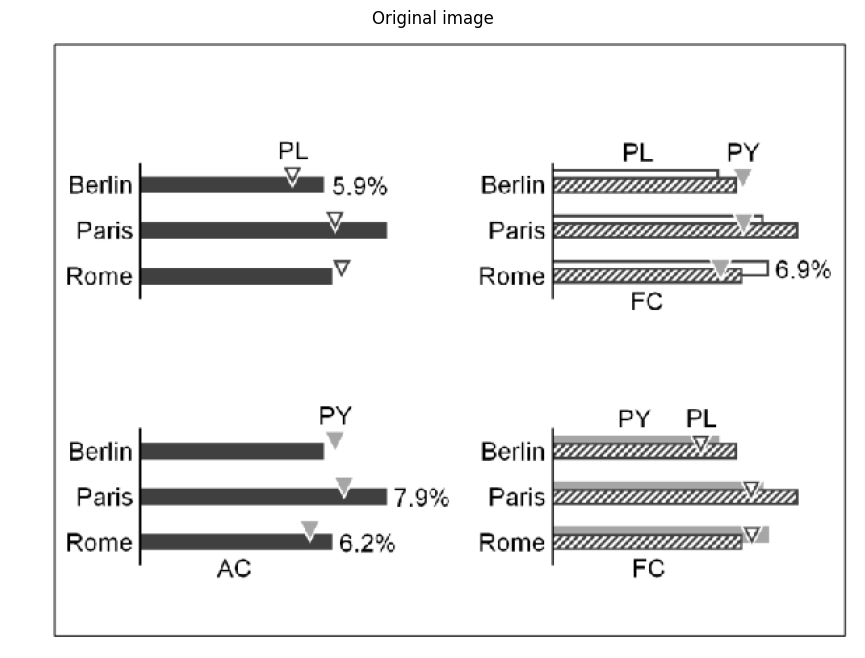

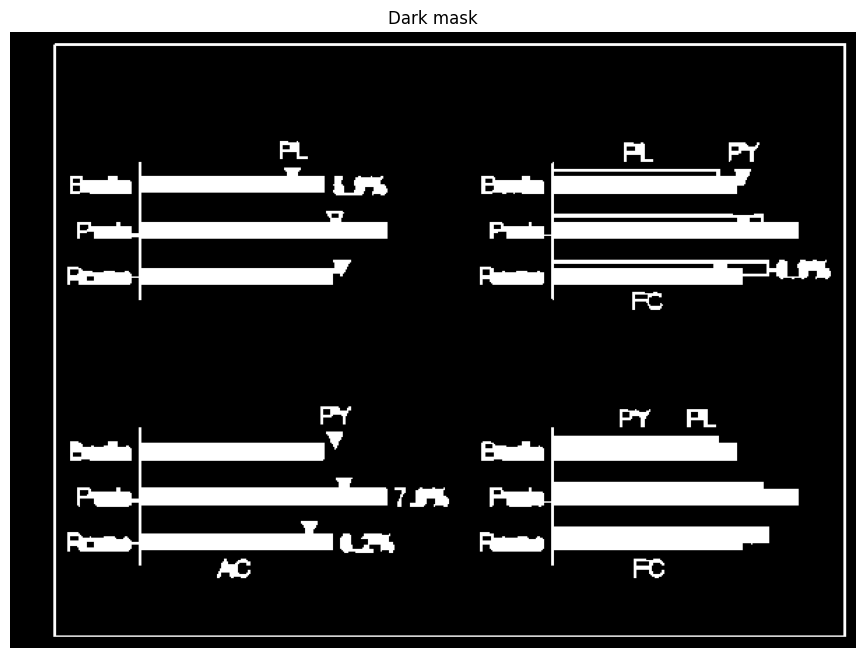

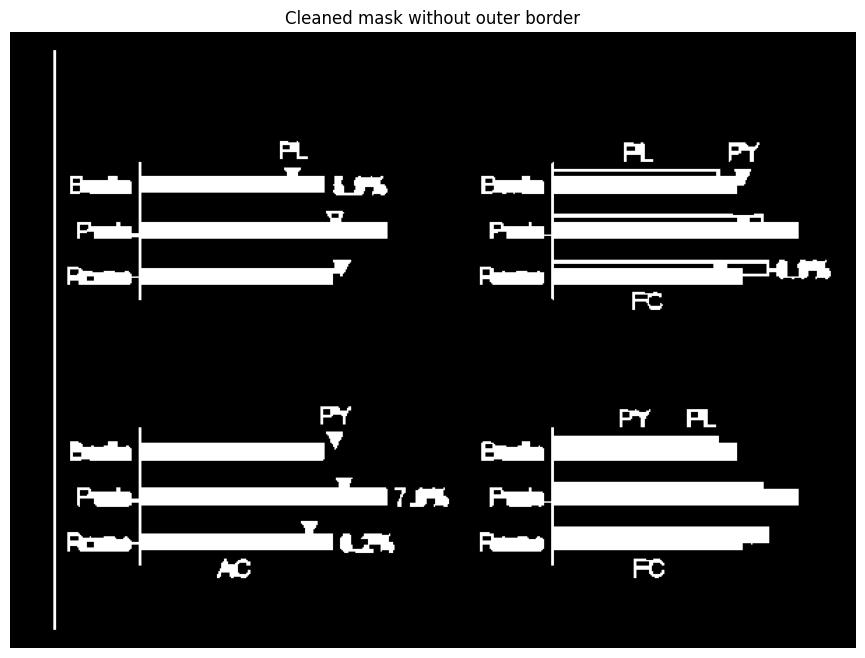

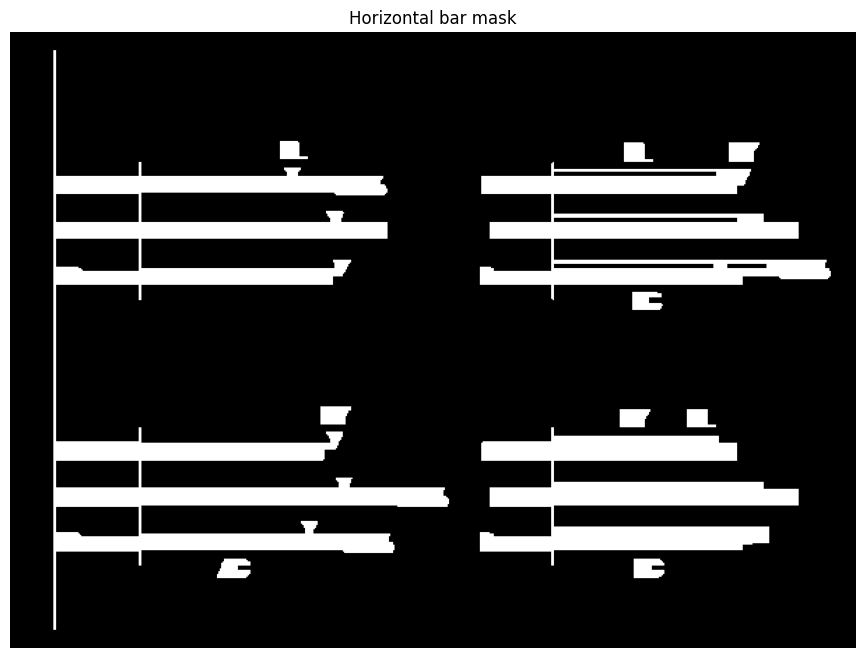

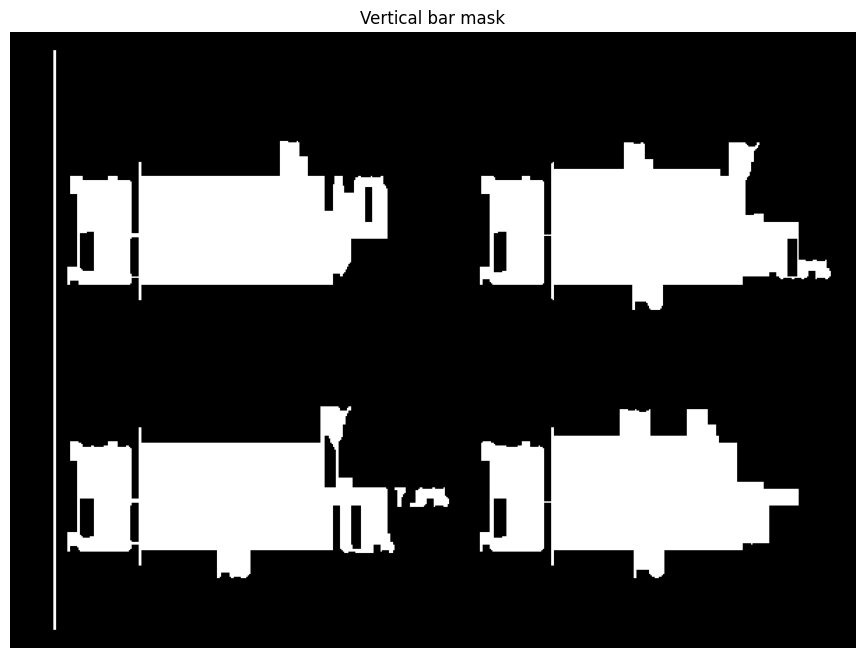

Horizontal bar candidates: 0
Vertical bar candidates: 0
Decision: mixed/unclear -> both axis types
Detected axes: 0


In [4]:
image = load_image(IMAGE_PATH)
show_image("Original image", image)

result = run_smart_axis_detection(image)

show_image("Dark mask", result["dark_mask"])
show_image("Cleaned mask without outer border", result["cleaned_mask"])
show_image("Horizontal bar mask", result["horizontal_bar_mask"])
show_image("Vertical bar mask", result["vertical_bar_mask"])

print("Horizontal bar candidates:", len(result["horizontal_bars"]))
print("Vertical bar candidates:", len(result["vertical_bars"]))
print("Decision:", result["decision"])
print("Detected axes:", len(result["axes"]))

## 4. Final result

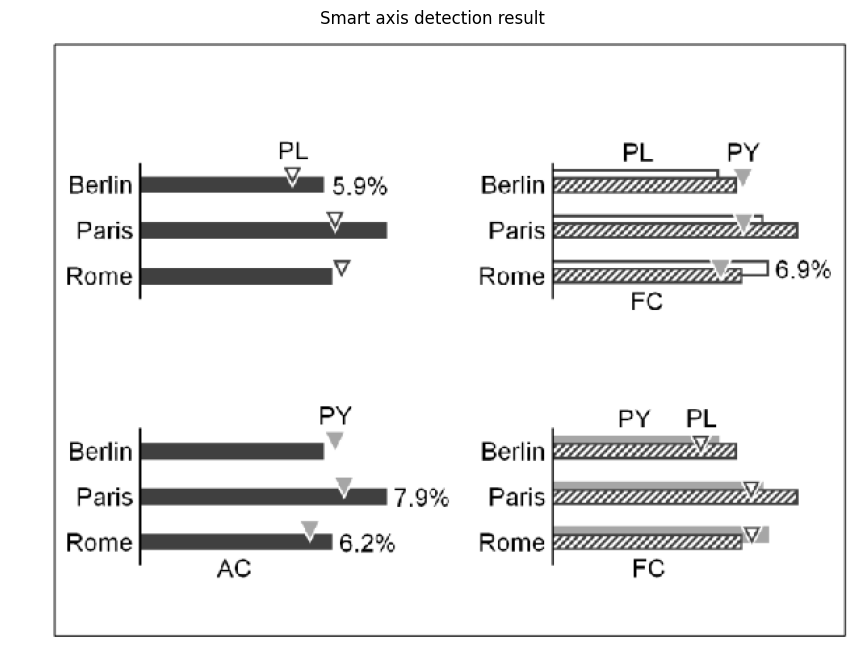

Saved to: ..\output\7_smart_axis_detection.png


In [5]:
output = draw_result(image, result, max_axes=MAX_AXES_TO_DRAW)
show_image("Smart axis detection result", output)

output_path = OUTPUT_DIR / f"{IMAGE_PATH.stem}_smart_axis_detection.png"
cv2.imwrite(str(output_path), output)

print("Saved to:", output_path)

## 5. Axis coordinates and explanation

In [ ]:
axes_df = axes_to_dataframe(result["axes"])
axes_df

## 6. Batch test all images

In [ ]:
DATASET_DIR = Path("../Dataset")
BATCH_OUTPUT_DIR = OUTPUT_DIR / "smart_axis_detection_batch"
BATCH_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

image_extensions = [".png", ".jpg", ".jpeg", ".webp"]
image_paths = []

for ext in image_extensions:
    image_paths.extend(DATASET_DIR.rglob(f"*{ext}"))

print("Found images:", len(image_paths))

summary = []

for path in image_paths:
    try:
        img = load_image(path)
        res = run_smart_axis_detection(img)
        out = draw_result(img, res, max_axes=MAX_AXES_TO_DRAW)

        relative = path.relative_to(DATASET_DIR)
        save_path = BATCH_OUTPUT_DIR / relative
        save_path.parent.mkdir(parents=True, exist_ok=True)

        cv2.imwrite(str(save_path), out)

        summary.append({
            "image": str(relative),
            "horizontal_bar_candidates": len(res["horizontal_bars"]),
            "vertical_bar_candidates": len(res["vertical_bars"]),
            "decision": res["decision"],
            "axes_detected": len(res["axes"]),
            "best_score": round(res["axes"][0]["score"], 1) if res["axes"] else None,
            "output": str(save_path)
        })

        print("Saved:", save_path)

    except Exception as e:
        print("Error with", path, ":", e)

summary_df = pd.DataFrame(summary)
summary_df

## 7. Report explanation

You can use this text:

> This notebook uses a rule-based OpenCV method to detect possible chart axes. The method combines three indicators. First, it detects bar-like shapes and checks whether multiple bars start or end on the same line. Second, it checks whether a dark axis line is visible at that location, because true axes are often shown as black or dark grey lines. Third, it applies penalties for likely dividers, borders and long layout lines, because these can look similar to axes but do not have enough bar support. The method is also orientation-aware: for horizontal bar charts it searches for left-side axes where bars start, while for vertical bar charts it searches for bottom x-axes where bars end. The final output contains possible axis candidates with coordinates, scores and explanation reasons.

Limitation:

> This is not a trained deep learning model. It is a rule-based computer vision pipeline. It can still fail when bars are not clearly detected, when charts are very small, or when text/dividers look similar to bars and axes. Therefore, the detections should be interpreted as candidates and evaluated visually.
